In [1]:
# =========================
# 1. Imports
# =========================
import os
import gc
import json
import math
import copy
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mne
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from tqdm import tqdm

In [2]:
# =========================
# 2. Paths and config
# =========================
DATA_DIR = Path("/kaggle/input/datasets/mok18976/bci-4-2a/BCICIV_2a")
WORK_DIR = Path("/kaggle/working/")

ARTIFACTS_DIR = WORK_DIR / "artifacts"
MODELS_DIR = WORK_DIR / "saved_models"
FIGURES_DIR = WORK_DIR / "figures"
HISTORY_DIR = WORK_DIR / "history"


ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
HISTORY_DIR.mkdir(parents=True, exist_ok=True)

SUBJECTS = [f"A{i:02d}" for i in range(1, 10)]

In [3]:
# -------------------------
# Training setup
# -------------------------
SEED = 42
TARGET_SFREQ = 128 #Target Downsampling Rate
#We extract from 0.5 sec to 2.5sec because lower than 0.5 contains more noices because it is the starting point of the activity
TMIN = 0.5 
TMAX = 2.5

N_CLASSES = 4 # 4 classes in data set
N_CHANNELS = 22 #22EEG channels Exist

# Use EEGNet-8,2  parameters
F1 = 8 #Number of temporal Filters
D = 2 #Number of depthwise Filters
F2 = 16 #number of separable Filters
KERNEL_LENGTH = 32 #Length of the convolutional kernal in the temporal dimentions
DROPOUT = 0.5 #During training randomly drom 50% neurons to prevent overfitting

# optimization
BATCH_SIZE = 64 #number of samples processed befre the model updates its weights
LR = 1e-3 #initial LR
WEIGHT_DECAY = 1e-4 #Regulatization parameter
MAX_EPOCHS = 120 
N_FOLDS = 4 #Number of Folds


TEST_SIZE = 0.20 #Separate 20% of data for testing


# augmentation
AUG_PROB = 0.3 #there’s a 70% chance that an EEG trial will be augmented.
GAUSSIAN_NOISE_STD = 0.005 #standered deviation of gaussian noise added to the EEG
AMPLITUDE_SCALE_RANGE = (0.95, 1.05) #Randm Scaling Factor
TIME_MASK_MAX_WIDTH = 8 #“hides” short segments of the signal, forcing the model to learn from incomplete data.


# GPU-focused settings
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP = torch.cuda.is_available()
PIN_MEMORY = torch.cuda.is_available()
NUM_WORKERS = 0 if torch.cuda.is_available() else 0
PERSISTENT_WORKERS = False if NUM_WORKERS > 0 else False
torch.backends.cudnn.benchmark = True


TRAIN_EVENT_CODE_TO_LABEL = {
    "769": 0,  # left hand
    "770": 1,  # right hand
    "771": 2,  # feet
    "772": 3,  # tongue
}


LABEL_TO_NAME = {
    0: "left_hand",
    1: "right_hand",
    2: "feet",
    3: "tongue",
}

In [4]:
# =========================
# 3. Reproducibility
# =========================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(SEED)

print("DEVICE:", DEVICE)
print("USE_AMP:", USE_AMP)

DEVICE: cuda
USE_AMP: True


In [5]:
# =========================
# 4. Utility functions
# =========================

#Counting the Number of Parameters of the model
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())


#Count Trainable parameters of the model
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


#store Python objects in a structured, portable format
#Converts Python objects (like dictionaries, lists, configs, results) into JSON text so they can be saved to disk.
#Human Readable

def save_json(obj, path):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)


#Get the label distribution
def print_label_distribution(y, title="Label distribution"):
    print(f"\n{title}")
    total = len(y)
    counter = Counter(y.tolist())
    for cls in sorted(counter.keys()):
        print(f"  class {cls} ({LABEL_TO_NAME[cls]}): {counter[cls]} ({100*counter[cls]/total:.2f}%)")
    print(f"  total: {total}")



#Print Split Summery
def print_split_summary(train_idx, val_idx, y_trainval, test_idx=None, y_full=None, title="Split Summary"):
    print("\n" + "="*80)
    print(title)
    print("="*80)
    print(f"Train size: {len(train_idx)}")
    print_label_distribution(y_trainval[train_idx], "Train labels")

    print(f"\nVal size: {len(val_idx)}")
    print_label_distribution(y_trainval[val_idx], "Val labels")

    if test_idx is not None and y_full is not None:
        print(f"\nTest size: {len(test_idx)}")
        print_label_distribution(y_full[test_idx], "Test labels")
    print("="*80)



#Plot Example Signals
def plot_signal_examples(raw_epochs, proc_epochs, labels, subject_id, ch_idx=0, n_examples=3):
    n_examples = min(n_examples, len(raw_epochs))
    fig, axes = plt.subplots(n_examples, 2, figsize=(14, 4*n_examples))
    if n_examples == 1:
        axes = np.array([axes])

    for i in range(n_examples):
        axes[i, 0].plot(raw_epochs[i, ch_idx])
        axes[i, 0].set_title(f"{subject_id} BEFORE preprocessing | sample {i} | label={LABEL_TO_NAME[int(labels[i])]}")
        axes[i, 0].set_xlabel("Time")
        axes[i, 0].set_ylabel("Amplitude")

        axes[i, 1].plot(proc_epochs[i, ch_idx])
        axes[i, 1].set_title(f"{subject_id} AFTER preprocessing | sample {i} | label={LABEL_TO_NAME[int(labels[i])]}")
        axes[i, 1].set_xlabel("Time")
        axes[i, 1].set_ylabel("Amplitude")

    plt.tight_layout()
    plt.show()



#Plot Training Curves
def plot_training_curves(history, title="Training Curves", save_path=None):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs, history["train_loss"], label="train_loss")
    axes[0].plot(epochs, history["val_loss"], label="val_loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(epochs, history["train_acc"], label="train_acc")
    axes[1].plot(epochs, history["val_acc"], label="val_acc")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True)

    fig.suptitle(title)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()




#Plot Confusion Matrix
def plot_conf_matrix(y_true, y_pred, title="Confusion Matrix", save_path=None):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[LABEL_TO_NAME[i] for i in range(N_CLASSES)]
    )
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    plt.title(title)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


#Print the model summert
def print_model_summary(model, input_shape=(1, 1, 22, 256)):
    print("\n" + "="*80)
    print("MODEL SUMMARY")
    print("="*80)
    print(model)
    print("-"*80)
    print(f"Total parameters     : {count_parameters(model):,}")
    print(f"Trainable parameters : {count_trainable_parameters(model):,}")
    with torch.no_grad():
        x = torch.randn(*input_shape).to(DEVICE)
        y = model(x)
        print(f"Input shape          : {tuple(x.shape)}")
        print(f"Output shape         : {tuple(y.shape)}")
    print("="*80)

In [6]:
# =========================
# 5. Data loading (T.gdf only)
# =========================


#Get the subject Path
def get_subject_t_path(subject_id):
    path = DATA_DIR / f"{subject_id}T.gdf"
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    return path


#Print the preview of the subject path
def print_annotation_info(gdf_path):
    raw = mne.io.read_raw_gdf(gdf_path, preload=False, verbose=False)
    _, event_id = mne.events_from_annotations(raw, verbose=False)
    print(f"\n{gdf_path.name}")
    print("Available annotation codes:", sorted(event_id.keys()))



#Load Raw gdt files
def load_raw_gdf(gdf_path, target_sfreq=128, l_freq=4.0, h_freq=40.0, notch_freq=None):
    raw = mne.io.read_raw_gdf(gdf_path, preload=True, verbose=False)

    # keep EEG only, remove EOG completely
    raw.pick_types(eeg=True, eog=False, misc=False, stim=False, exclude=[])

    # band-pass filter for SMR
    raw.filter(
        l_freq=l_freq,
        h_freq=h_freq,
        fir_design="firwin",
        verbose=False
    )

    # optional notch filter
    if notch_freq is not None:
        raw.notch_filter(freqs=[notch_freq], verbose=False)

    # resample to 128 Hz
    raw.resample(target_sfreq, npad="auto", verbose=False)

    return raw

#Get the data and get from 0.5 to 2.5 
def extract_train_epochs(raw, tmin=0.5, tmax=2.5):
    events, event_id = mne.events_from_annotations(raw, verbose=False)
    inverse_event_id = {v: k for k, v in event_id.items()}

    valid_codes = []
    for code_str in TRAIN_EVENT_CODE_TO_LABEL:
        if code_str in event_id:
            valid_codes.append(event_id[code_str])

    if len(valid_codes) == 0:
        raise ValueError(
            f"No cue events found. Available codes: {list(event_id.keys())}"
        )

    selected_events = events[np.isin(events[:, 2], valid_codes)]

    y = []
    for e in selected_events:
        code_str = inverse_event_id[e[2]]
        y.append(TRAIN_EVENT_CODE_TO_LABEL[code_str])
    y = np.asarray(y, dtype=np.int64)

    epochs = mne.Epochs(
        raw,
        events=selected_events,
        event_id=None,
        tmin=tmin,
        tmax=tmax,
        baseline=None,
        preload=True,
        verbose=False,
    )

    X = epochs.get_data(copy=True)  # [N, C, T]
    return X, y



#Function for loading data of one subject
def load_subject_data(subject_id, l_freq=4.0, h_freq=40.0, notch_freq=None):
    gdf_path = get_subject_t_path(subject_id)
    raw = load_raw_gdf(
        gdf_path,
        target_sfreq=TARGET_SFREQ,
        l_freq=l_freq,
        h_freq=h_freq,
        notch_freq=notch_freq
    )
    X, y = extract_train_epochs(raw, tmin=TMIN, tmax=TMAX)
    return X, y

In [7]:
# =========================
# 6. Normalization
# =========================
class ChannelwiseZScore:
    def __init__(self, eps=1e-6):
        self.mean = None
        self.std = None
        self.eps = eps

    def fit(self, X):
        self.mean = X.mean(axis=(0, 2), keepdims=True)
        self.std = X.std(axis=(0, 2), keepdims=True)
        self.std = np.maximum(self.std, self.eps)
        return self

    def transform(self, X):
        return (X - self.mean) / self.std  #Apply z-score equation

    def fit_transform(self, X):
        return self.fit(X).transform(X)

In [8]:
# =========================
# 7. Data augmentation
# =========================

class EEGAugment:
    def __init__(
        self,
        p=AUG_PROB,
        noise_std=GAUSSIAN_NOISE_STD,
        scale_range=AMPLITUDE_SCALE_RANGE,
        time_mask_max_width=TIME_MASK_MAX_WIDTH
    ):
        self.p = p #probability of applying augmentation
        self.noise_std = noise_std #standered deviation of gaussian noise
        self.scale_range = scale_range #rnage of amplification
        self.time_mask_max_width = time_mask_max_width #maximum width of mask

    def __call__(self, x):
        # x: [C, T]
        x = x.copy() #make copy of the data and modifying, Original data want be modified

        if random.random() < self.p:
            # Gaussian noise
            noise = np.random.randn(*x.shape).astype(np.float32) * self.noise_std
            x = x + noise

        if random.random() < self.p:
            # amplitude scaling
            scale = np.random.uniform(self.scale_range[0], self.scale_range[1])
            x = x * scale

        if random.random() < self.p:
            # time masking
            T = x.shape[1]
            width = random.randint(1, min(self.time_mask_max_width, T))
            start = random.randint(0, T - width)
            x[:, start:start+width] = 0.0

        return x

In [9]:
# =========================
# 8. Dataset and loaders
#This block is building the data pipeline that connects your EEG data to PyTorch training. 
# =========================
class EEGDataset(Dataset):
    def __init__(self, X, y, augment=None):
        self.X = X.astype(np.float32)
        self.y = y.astype(np.int64)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]   # [C, T]
        y = self.y[idx]

        if self.augment is not None:
            x = self.augment(x)

        x = torch.tensor(x, dtype=torch.float32).unsqueeze(0)  # [1, C, T]
        y = torch.tensor(y, dtype=torch.long)
        return x, y


#Create training and Validation loaders
def make_loaders(X_tr, y_tr, X_va, y_va, batch_size=BATCH_SIZE, use_aug=True):
    train_aug = EEGAugment() if use_aug else None
    train_ds = EEGDataset(X_tr, y_tr, augment=train_aug)
    val_ds = EEGDataset(X_va, y_va, augment=None)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=PERSISTENT_WORKERS,
        drop_last=False,
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=PERSISTENT_WORKERS,
        drop_last=False,
    )
    return train_loader, val_loader

def make_test_loader(X_te, y_te, batch_size=BATCH_SIZE):
    test_ds = EEGDataset(X_te, y_te, augment=None)
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=PERSISTENT_WORKERS,
        drop_last=False,
    )
    return test_loader

In [10]:
# =========================
# 9. EEGNet model 
# =========================
class Conv2dWithConstraint(nn.Conv2d):
    def __init__(self, *args, max_norm=1.0, do_weight_norm=True, **kwargs):
        super().__init__(*args, **kwargs)
        self.max_norm = max_norm
        self.do_weight_norm = do_weight_norm

    def forward(self, x):
        if self.do_weight_norm:
            with torch.no_grad():
                w = self.weight.data
                norm = torch.norm(w.view(w.size(0), -1), p=2, dim=1, keepdim=True)
                desired = torch.clamp(norm, max=self.max_norm)
                w = w * (desired / (1e-8 + norm)).view(-1, 1, 1, 1)
                self.weight.data = w
        return super().forward(x)

class LinearWithConstraint(nn.Linear):
    def __init__(self, *args, max_norm=0.25, do_weight_norm=True, **kwargs):
        super().__init__(*args, **kwargs)
        self.max_norm = max_norm
        self.do_weight_norm = do_weight_norm

    def forward(self, x):
        if self.do_weight_norm:
            with torch.no_grad():
                w = self.weight.data
                norm = torch.norm(w, p=2, dim=1, keepdim=True)
                desired = torch.clamp(norm, max=self.max_norm)
                self.weight.data = w * (desired / (1e-8 + norm))
        return super().forward(x)

#make EEGnet class
class EEGNet(nn.Module):
    def __init__(
        self,
        n_chans=22,
        n_classes=4,
        input_time_length=256,
        F1=8,
        D=2,
        F2=16,
        kernel_length=32,
        dropout=0.5,
    ):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=F1,
                kernel_size=(1, kernel_length),
                stride=1,
                padding="same",
                bias=False
            ),
            nn.BatchNorm2d(F1),

            Conv2dWithConstraint(
                in_channels=F1,
                out_channels=F1 * D,
                kernel_size=(n_chans, 1),
                groups=F1,
                bias=False,
                max_norm=1.0,
                do_weight_norm=True
            ),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),
            nn.Dropout(dropout),
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(
                in_channels=F1 * D,
                out_channels=F1 * D,
                kernel_size=(1, 16),
                stride=1,
                padding="same",
                groups=F1 * D,
                bias=False
            ),
            nn.Conv2d(
                in_channels=F1 * D,
                out_channels=F2,
                kernel_size=(1, 1),
                stride=1,
                bias=False
            ),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout(dropout),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_chans, input_time_length)
            out = self.block1(dummy)
            out = self.block2(out)
            self.feature_dim = out.numel()

        self.classifier = LinearWithConstraint(
            self.feature_dim, n_classes, max_norm=0.25, do_weight_norm=True
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = torch.flatten(x, start_dim=1)
        x = self.classifier(x)
        return x

In [11]:
# =========================
# 10. Train / eval functions
# =========================
def run_one_epoch(model, loader, criterion, optimizer=None, scaler=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    losses = []
    all_preds = []
    all_targets = []

    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            if USE_AMP:
                with torch.amp.autocast(device_type="cuda"):
                    logits = model(xb)
                    loss = criterion(logits, yb)
            else:
                logits = model(xb)
                loss = criterion(logits, yb)

            if is_train:
                if USE_AMP:
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    optimizer.step()

        preds = logits.argmax(dim=1)

        losses.append(loss.item())
        all_preds.append(preds.detach().cpu().numpy())
        all_targets.append(yb.detach().cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    acc = accuracy_score(all_targets, all_preds)
    loss = float(np.mean(losses))

    return loss, acc, all_targets, all_preds

@torch.no_grad()


@torch.no_grad()
def evaluate_model(model, loader, criterion):
    model.eval()
    losses = []
    all_preds = []
    all_targets = []
    all_logits = []

    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        if USE_AMP:
            with torch.amp.autocast(device_type="cuda"):
                logits = model(xb)
                loss = criterion(logits, yb)
        else:
            logits = model(xb)
            loss = criterion(logits, yb)

        preds = logits.argmax(dim=1)

        losses.append(loss.item())
        all_preds.append(preds.detach().cpu().numpy())
        all_targets.append(yb.detach().cpu().numpy())
        all_logits.append(logits.detach().cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    all_logits = np.concatenate(all_logits)

    acc = accuracy_score(all_targets, all_preds)
    loss = float(np.mean(losses))

    return loss, acc, all_targets, all_preds, all_logits

In [12]:
# =========================
# 11. One-fold training
# =========================
def train_one_fold(
    subject_id,
    fold_id,
    X_train_fold,
    y_train_fold,
    X_val_fold,
    y_val_fold,
    batch_size=BATCH_SIZE,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    max_epochs=MAX_EPOCHS,
):
    scaler_norm = ChannelwiseZScore().fit(X_train_fold)
    X_train_fold_norm = scaler_norm.transform(X_train_fold)
    X_val_fold_norm = scaler_norm.transform(X_val_fold)

    train_loader, val_loader = make_loaders(
        X_train_fold_norm, y_train_fold,
        X_val_fold_norm, y_val_fold,
        batch_size=batch_size,
        use_aug=True
    )

    model = EEGNet(
        n_chans=X_train_fold.shape[1],
        n_classes=N_CLASSES,
        input_time_length=X_train_fold.shape[-1],
        F1=F1,
        D=D,
        F2=F2,
        kernel_length=KERNEL_LENGTH,
        dropout=DROPOUT
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=max_epochs,
        eta_min=1e-5
    )
    amp_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    best_val_acc = -1.0
    best_state = None

    history = {
        "epoch": [],
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "lr": [],
    }

    best_model_path = MODELS_DIR / f"{subject_id}_fold{fold_id}_best_acc.pt"
    last_model_path = MODELS_DIR / f"{subject_id}_fold{fold_id}_last.pt"

    epoch_bar = tqdm(
        range(1, max_epochs + 1),
        desc=f"{subject_id} Fold {fold_id}",
        leave=True,
        dynamic_ncols=True
    )

    for epoch in epoch_bar:
        current_lr = optimizer.param_groups[0]["lr"]

        train_loss, train_acc, _, _ = run_one_epoch(
            model, train_loader, criterion,
            optimizer=optimizer, scaler=amp_scaler
        )

        val_loss, val_acc, _, _ = run_one_epoch(
            model, val_loader, criterion,
            optimizer=None, scaler=None
        )

        scheduler.step()

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            torch.save(
                {
                    "subject": subject_id,
                    "fold": fold_id,
                    "epoch": epoch,
                    "model_state_dict": best_state,
                    "val_acc": best_val_acc,
                    "config": {
                        "F1": F1, "D": D, "F2": F2,
                        "kernel_length": KERNEL_LENGTH,
                        "dropout": DROPOUT
                    }
                },
                best_model_path
            )

        torch.save(
            {
                "subject": subject_id,
                "fold": fold_id,
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "val_acc": val_acc,
                "config": {
                    "F1": F1, "D": D, "F2": F2,
                    "kernel_length": KERNEL_LENGTH,
                    "dropout": DROPOUT
                }
            },
            last_model_path
        )

        epoch_bar.set_postfix(
            tr_loss=f"{train_loss:.4f}",
            tr_acc=f"{train_acc:.4f}",
            va_loss=f"{val_loss:.4f}",
            va_acc=f"{val_acc:.4f}",
            best=f"{best_val_acc:.4f}",
            lr=f"{current_lr:.5f}"
        )

    model.load_state_dict(best_state)
    val_loss, val_acc, val_true, val_pred, val_logits = evaluate_model(model, val_loader, criterion)

    history_path = HISTORY_DIR / f"{subject_id}_fold{fold_id}_history.json"
    save_json(history, history_path)

    return {
        "model": model,
        "norm_scaler": scaler_norm,
        "history": history,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "y_true": val_true,
        "y_pred": val_pred,
        "y_logits": val_logits,
        "best_model_path": str(best_model_path),
        "last_model_path": str(last_model_path),
    }

In [13]:
# =========================
# 12. Final retrain on trainval, test on holdout
# =========================
def train_final_model(
    subject_id,
    X_trainval,
    y_trainval,
    X_test,
    y_test,
    batch_size=BATCH_SIZE,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    max_epochs=MAX_EPOCHS,
):
    scaler_norm = ChannelwiseZScore().fit(X_trainval)
    X_trainval_norm = scaler_norm.transform(X_trainval)
    X_test_norm = scaler_norm.transform(X_test)

    train_loader = make_loaders(
        X_trainval_norm, y_trainval,
        X_test_norm[:1], y_test[:1],
        batch_size=batch_size,
        use_aug=True
    )[0]

    test_loader = make_test_loader(X_test_norm, y_test, batch_size=batch_size)

    model = EEGNet(
        n_chans=X_trainval.shape[1],
        n_classes=N_CLASSES,
        input_time_length=X_trainval.shape[-1],
        F1=F1,
        D=D,
        F2=F2,
        kernel_length=KERNEL_LENGTH,
        dropout=DROPOUT
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=max_epochs,
        eta_min=1e-5
    )
    amp_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    best_test_acc_proxy = -1.0
    best_state = None

    history = {
        "epoch": [],
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],
        "lr": [],
    }

    best_model_path = MODELS_DIR / f"{subject_id}_final_best_acc.pt"
    last_model_path = MODELS_DIR / f"{subject_id}_final_last.pt"

    epoch_bar = tqdm(
        range(1, max_epochs + 1),
        desc=f"{subject_id} Final",
        leave=True,
        dynamic_ncols=True
    )

    for epoch in epoch_bar:
        current_lr = optimizer.param_groups[0]["lr"]

        train_loss, train_acc, _, _ = run_one_epoch(
            model, train_loader, criterion,
            optimizer=optimizer, scaler=amp_scaler
        )

        test_loss, test_acc, _, _, _ = evaluate_model(model, test_loader, criterion)

        scheduler.step()

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
        history["lr"].append(current_lr)

        if test_acc > best_test_acc_proxy:
            best_test_acc_proxy = test_acc
            best_state = copy.deepcopy(model.state_dict())
            torch.save(
                {
                    "subject": subject_id,
                    "epoch": epoch,
                    "model_state_dict": best_state,
                    "test_acc": best_test_acc_proxy,
                },
                best_model_path
            )

        torch.save(
            {
                "subject": subject_id,
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "test_acc": test_acc,
            },
            last_model_path
        )

        epoch_bar.set_postfix(
            tr_loss=f"{train_loss:.4f}",
            tr_acc=f"{train_acc:.4f}",
            te_loss=f"{test_loss:.4f}",
            te_acc=f"{test_acc:.4f}",
            best=f"{best_test_acc_proxy:.4f}",
            lr=f"{current_lr:.5f}"
        )

    model.load_state_dict(best_state)
    test_loss, test_acc, y_true, y_pred, y_logits = evaluate_model(model, test_loader, criterion)

    history_path = HISTORY_DIR / f"{subject_id}_final_history.json"
    save_json(history, history_path)

    per_class_acc = {}
    for cls_idx in range(N_CLASSES):
        mask = (y_true == cls_idx)
        cls_acc = float((y_pred[mask] == y_true[mask]).mean()) if mask.sum() > 0 else float("nan")
        per_class_acc[LABEL_TO_NAME[cls_idx]] = cls_acc

    report = classification_report(
        y_true,
        y_pred,
        target_names=[LABEL_TO_NAME[i] for i in range(N_CLASSES)],
        output_dict=True,
        zero_division=0
    )

    return {
        "model": model,
        "norm_scaler": scaler_norm,
        "history": history,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_logits": y_logits,
        "per_class_acc": per_class_acc,
        "classification_report": report,
        "best_model_path": str(best_model_path),
        "last_model_path": str(last_model_path),
    }

In [14]:
# =========================
# 13. Random 20-sample prediction demo
# =========================
@torch.no_grad()
def predict_random_20(model, scaler_norm, X_test, y_test, subject_id):
    n = min(20, len(X_test))
    idx = np.random.choice(len(X_test), size=n, replace=False)

    X_sel = scaler_norm.transform(X_test[idx])
    y_sel = y_test[idx]

    ds = EEGDataset(X_sel, y_sel, augment=None)
    loader = DataLoader(
        ds,
        batch_size=n,
        shuffle=False,
        num_workers=0,
        pin_memory=PIN_MEMORY
    )

    model.eval()
    xb, yb = next(iter(loader))
    xb = xb.to(DEVICE)

    if USE_AMP:
        with torch.cuda.amp.autocast():
            logits = model(xb)
    else:
        logits = model(xb)

    probs = torch.softmax(logits, dim=1).cpu().numpy()
    preds = logits.argmax(dim=1).cpu().numpy()
    true = yb.numpy()

    df = pd.DataFrame({
        "sample_index_in_test": idx,
        "true_label": [LABEL_TO_NAME[int(t)] for t in true],
        "pred_label": [LABEL_TO_NAME[int(p)] for p in preds],
        "correct": (true == preds).astype(int)
    })

    for c in range(N_CLASSES):
        df[f"prob_{LABEL_TO_NAME[c]}"] = probs[:, c]

    csv_path = ARTIFACTS_DIR / f"{subject_id}_random20_predictions.csv"
    df.to_csv(csv_path, index=False)

    print(f"\nRandom 20-sample predictions for {subject_id}")
    display(df)

    return df

In [15]:
# =========================
# 14. Subject pipeline
# =========================
def run_subject_pipeline(subject_id, visualize=True):
    print("\n" + "#"*100)
    print(f"SUBJECT {subject_id}")
    print("#"*100)

    # Load
    gdf_path = get_subject_t_path(subject_id)
    print_annotation_info(gdf_path)

    X_raw_epochs, y_all = load_subject_data(
    subject_id,
    l_freq=4.0,
    h_freq=38.0,
    notch_freq=None
    )
    print(f"\nLoaded shape: X={X_raw_epochs.shape}, y={y_all.shape}")
    print_label_distribution(y_all, f"{subject_id} full dataset labels")

    # Holdout test split from T.gdf
    sss = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEED)
    trainval_idx, test_idx = next(sss.split(X_raw_epochs, y_all))

    X_trainval_raw = X_raw_epochs[trainval_idx]
    y_trainval = y_all[trainval_idx]
    X_test_raw = X_raw_epochs[test_idx]
    y_test = y_all[test_idx]

    print(f"\nTrainVal shape: {X_trainval_raw.shape}, Test shape: {X_test_raw.shape}")
    print_label_distribution(y_trainval, f"{subject_id} trainval labels")
    print_label_distribution(y_test, f"{subject_id} test labels")

    # visualization before/after preprocessing on trainval example
    # "before" = raw epoch after extraction
    # "after" = normalized with trainval stats
    norm_for_vis = ChannelwiseZScore().fit(X_trainval_raw)
    X_trainval_vis = norm_for_vis.transform(X_trainval_raw)

    if visualize:
        plot_signal_examples(
            X_trainval_raw,
            X_trainval_vis,
            y_trainval,
            subject_id=subject_id,
            ch_idx=0,
            n_examples=3
        )

    # 4-fold CV on trainval
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

    fold_summaries = []
    cv_accs = []
    cv_losses = []

    # model summary once
    temp_model = EEGNet(
        n_chans=X_trainval_raw.shape[1],
        n_classes=N_CLASSES,
        input_time_length=X_trainval_raw.shape[-1],
        F1=F1,
        D=D,
        F2=F2,
        kernel_length=KERNEL_LENGTH,
        dropout=DROPOUT
    ).to(DEVICE)
    print_model_summary(temp_model, input_shape=(1, 1, X_trainval_raw.shape[1], X_trainval_raw.shape[-1]))
    del temp_model
    torch.cuda.empty_cache()

    for fold_id, (tr_idx, va_idx) in enumerate(skf.split(X_trainval_raw, y_trainval), start=1):
        print_split_summary(tr_idx, va_idx, y_trainval, test_idx=None, y_full=None, title=f"{subject_id} Fold {fold_id} summary")

        fold_out = train_one_fold(
            subject_id=subject_id,
            fold_id=fold_id,
            X_train_fold=X_trainval_raw[tr_idx],
            y_train_fold=y_trainval[tr_idx],
            X_val_fold=X_trainval_raw[va_idx],
            y_val_fold=y_trainval[va_idx],
            batch_size=BATCH_SIZE,
            lr=LR,
            weight_decay=WEIGHT_DECAY,
            max_epochs=MAX_EPOCHS,
        )

        cv_accs.append(fold_out["val_acc"])
        cv_losses.append(fold_out["val_loss"])

        #plot_training_curves(
         #   fold_out["history"],
          #  title=f"{subject_id} Fold {fold_id} Training Curves",
           # save_path=FIGURES_DIR / f"{subject_id}_fold{fold_id}_curves.png"
        #)

        #plot_conf_matrix(
         #   fold_out["y_true"],
          #  fold_out["y_pred"],
           # title=f"{subject_id} Fold {fold_id} Validation Confusion Matrix",
            #save_path=FIGURES_DIR / f"{subject_id}_fold{fold_id}_cm.png"
        #)

        fold_summary = {
            "fold": fold_id,
            "val_loss": float(fold_out["val_loss"]),
            "val_acc": float(fold_out["val_acc"]),
            "best_model_path": fold_out["best_model_path"],
            "last_model_path": fold_out["last_model_path"],
        }
        fold_summaries.append(fold_summary)

        del fold_out["model"]
        gc.collect()
        torch.cuda.empty_cache()

    cv_mean_acc = float(np.mean(cv_accs))
    cv_std_acc = float(np.std(cv_accs))
    cv_mean_loss = float(np.mean(cv_losses))
    cv_std_loss = float(np.std(cv_losses))

    print("\n" + "="*80)
    print(f"{subject_id} CV summary")
    print(f"CV acc  : {cv_mean_acc:.4f} ± {cv_std_acc:.4f}")
    print(f"CV loss : {cv_mean_loss:.4f} ± {cv_std_loss:.4f}")
    print("="*80)

    # Final retrain on full trainval and evaluate on holdout test
    final_out = train_final_model(
        subject_id=subject_id,
        X_trainval=X_trainval_raw,
        y_trainval=y_trainval,
        X_test=X_test_raw,
        y_test=y_test,
        batch_size=BATCH_SIZE,
        lr=LR,
        weight_decay=WEIGHT_DECAY,
        max_epochs=MAX_EPOCHS,
    )

    plot_training_curves(
        {
            "train_loss": final_out["history"]["train_loss"],
            "val_loss": final_out["history"]["test_loss"],
            "train_acc": final_out["history"]["train_acc"],
            "val_acc": final_out["history"]["test_acc"],
        },
        title=f"{subject_id} Final Train/Test Curves",
        save_path=FIGURES_DIR / f"{subject_id}_final_curves.png"
    )

    plot_conf_matrix(
        final_out["y_true"],
        final_out["y_pred"],
        title=f"{subject_id} Holdout Test Confusion Matrix",
        save_path=FIGURES_DIR / f"{subject_id}_final_test_cm.png"
    )

    print(f"\n{subject_id} Holdout Test Loss: {final_out['test_loss']:.4f}")
    print(f"{subject_id} Holdout Test Acc : {final_out['test_acc']:.4f}")
    print("Per-class accuracy:")
    for k, v in final_out["per_class_acc"].items():
        print(f"  {k}: {v:.4f}")

    random20_df = predict_random_20(
        final_out["model"],
        final_out["norm_scaler"],
        X_test_raw,
        y_test,
        subject_id=subject_id
    )

    # save summary
    subject_summary = {
        "subject": subject_id,
        "cv_mean_acc": cv_mean_acc,
        "cv_std_acc": cv_std_acc,
        "cv_mean_loss": cv_mean_loss,
        "cv_std_loss": cv_std_loss,
        "holdout_test_loss": float(final_out["test_loss"]),
        "holdout_test_acc": float(final_out["test_acc"]),
        "per_class_acc": final_out["per_class_acc"],
        "fold_summaries": fold_summaries,
        "final_best_model_path": final_out["best_model_path"],
        "final_last_model_path": final_out["last_model_path"],
    }

    save_json(subject_summary, ARTIFACTS_DIR / f"{subject_id}_summary.json")

    return subject_summary


####################################################################################################
SUBJECT A01
####################################################################################################


/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)



A01T.gdf
Available annotation codes: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]


/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).

Loaded shape: X=(288, 25, 257), y=(288,)

A01 full dataset labels
  class 0 (left_hand): 72 (25.00%)
  class 1 (right_hand): 72 (25.00%)
  class 2 (feet): 72 (25.00%)
  class 3 (tongue): 72 (25.00%)
  total: 288

TrainVal shape: (230, 25, 257), Test shape: (58, 25, 257)

A01 trainval labels
  class 0 (left_hand): 57 (24.78%)
  class 1 (right_hand): 58 (25.22%)
  class 2 (feet): 57 (24.78%)
  class 3 (tongue): 58 (25.22%)
  total: 230

A01 test labels
  class 0 (left_hand): 15 (25.86%)
  class 1 (right_hand): 14 (24.14%)
  class 2 (feet): 15 (25.86%)
  class 3 (tongue): 14 (24.14%)
  total: 58


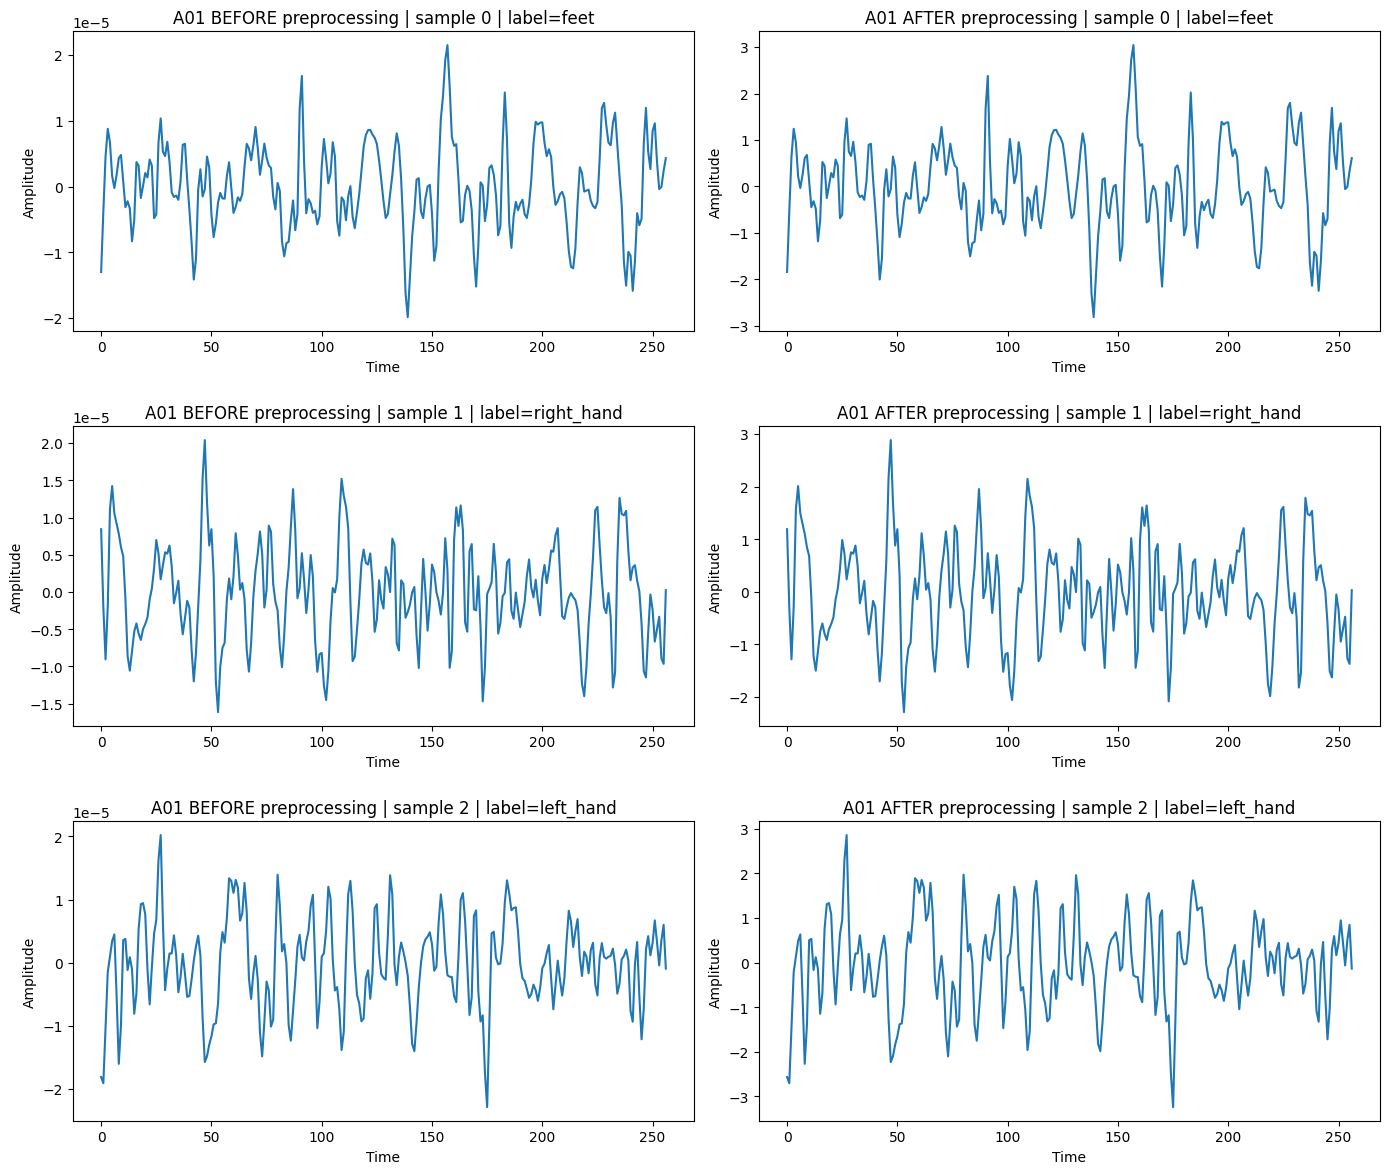

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/conv.py:543: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1031.)
  return F.conv2d(



MODEL SUMMARY
EEGNet(
  (block1): Sequential(
    (0): Conv2d(1, 8, kernel_size=(1, 32), stride=(1, 1), padding=same, bias=False)
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Conv2dWithConstraint(8, 16, kernel_size=(25, 1), stride=(1, 1), groups=8, bias=False)
    (3): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ELU(alpha=1.0)
    (5): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
    (6): Dropout(p=0.5, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(16, 16, kernel_size=(1, 16), stride=(1, 1), padding=same, groups=16, bias=False)
    (1): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ELU(alpha=1.0)
    (4): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
    (5): Dropout(p=0.5, inplace=False)
  )
  (classifier): LinearWithConstraint(in_features=128

/tmp/ipykernel_55/2653629609.py:45: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  amp_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
A01 Fold 1: 100%|██████████| 120/120 [00:09<00:00, 12.51it/s, best=0.6552, lr=0.00001, tr_acc=0.5756, tr_loss=0.8508, va_acc=0.6379, va_loss=0.8305]
/tmp/ipykernel_55/2653629609.py:45: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  amp_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)



A01 Fold 2 summary
Train size: 172

Train labels
  class 0 (left_hand): 43 (25.00%)
  class 1 (right_hand): 43 (25.00%)
  class 2 (feet): 43 (25.00%)
  class 3 (tongue): 43 (25.00%)
  total: 172

Val size: 58

Val labels
  class 0 (left_hand): 14 (24.14%)
  class 1 (right_hand): 15 (25.86%)
  class 2 (feet): 14 (24.14%)
  class 3 (tongue): 15 (25.86%)
  total: 58


A01 Fold 2: 100%|██████████| 120/120 [00:06<00:00, 19.84it/s, best=0.5690, lr=0.00001, tr_acc=0.6105, tr_loss=0.8490, va_acc=0.5345, va_loss=0.9040]
/tmp/ipykernel_55/2653629609.py:45: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  amp_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


...

A01 Fold 3: 100%|██████████| 120/120 [00:07<00:00, 16.98it/s, best=0.5789, lr=0.00001, tr_acc=0.5954, tr_loss=0.8767, va_acc=0.5789, va_loss=0.8600]
/tmp/ipykernel_55/2653629609.py:45: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  amp_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)



A01 Fold 4 summary
Train size: 173

Train labels
  class 0 (left_hand): 42 (24.28%)
  class 1 (right_hand): 44 (25.43%)
  class 2 (feet): 43 (24.86%)
  class 3 (tongue): 44 (25.43%)
  total: 173

Val size: 57

Val labels
  class 0 (left_hand): 15 (26.32%)
  class 1 (right_hand): 14 (24.56%)
  class 2 (feet): 14 (24.56%)
  class 3 (tongue): 14 (24.56%)
  total: 57


A01 Fold 4: 100%|██████████| 120/120 [00:05<00:00, 20.05it/s, best=0.5965, lr=0.00001, tr_acc=0.6069, tr_loss=0.8553, va_acc=0.5965, va_loss=0.8742]
/tmp/ipykernel_55/3925417988.py:46: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  amp_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)



A01 CV summary
CV acc  : 0.5999 ± 0.0334
CV loss : 0.8876 ± 0.0378


A01 Final: 100%|██████████| 120/120 [00:08<00:00, 13.86it/s, best=0.6379, lr=0.00001, te_acc=0.5517, te_loss=0.9206, tr_acc=0.6304, tr_loss=0.8463]


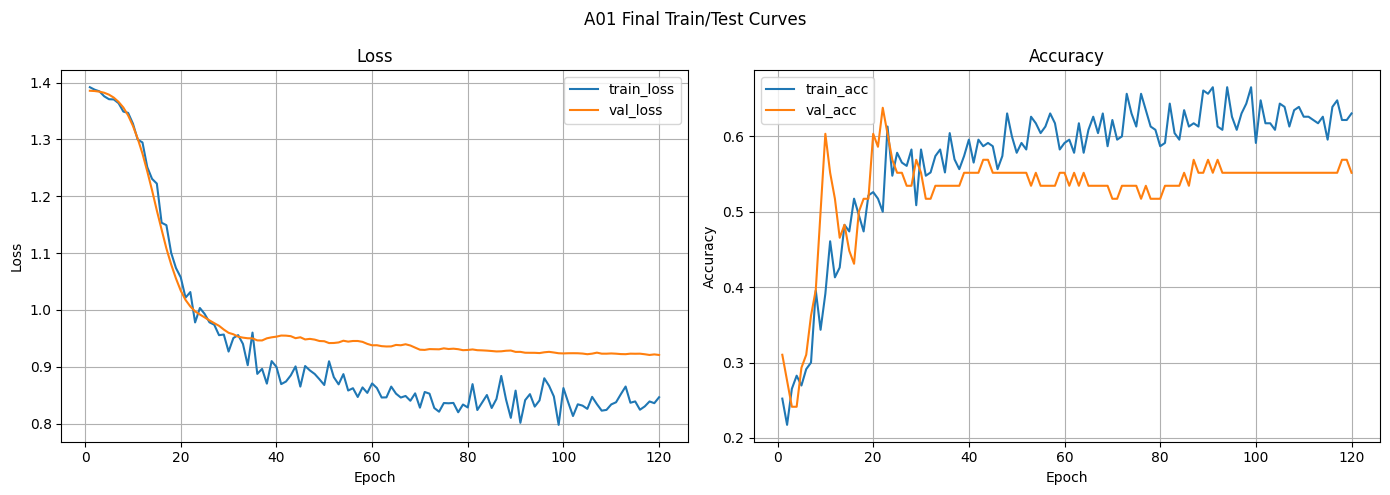

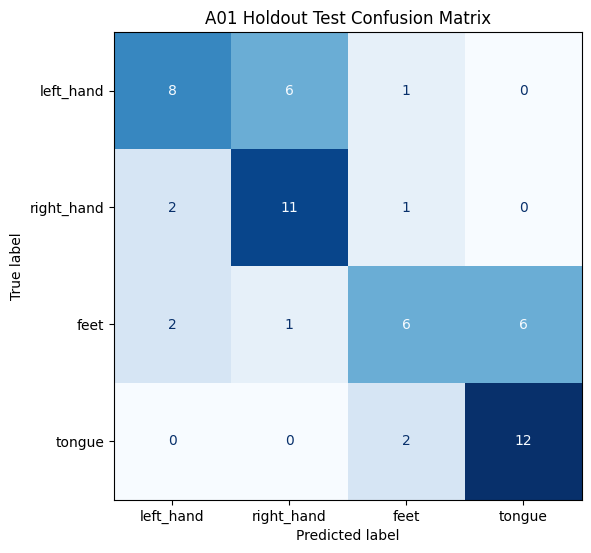


A01 Holdout Test Loss: 1.0061
A01 Holdout Test Acc : 0.6379
Per-class accuracy:
  left_hand: 0.5333
  right_hand: 0.7857
  feet: 0.4000
  tongue: 0.8571

Random 20-sample predictions for A01


/tmp/ipykernel_55/477152603.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,sample_index_in_test,true_label,pred_label,correct,prob_left_hand,prob_right_hand,prob_feet,prob_tongue
0,7,left_hand,right_hand,0,0.430908,0.439453,0.078308,0.051331
1,40,feet,left_hand,0,0.269775,0.252686,0.244995,0.232666
2,21,right_hand,right_hand,1,0.303711,0.319336,0.230347,0.146606
3,22,feet,tongue,0,0.152954,0.148071,0.302734,0.396240
4,29,left_hand,left_hand,1,0.338623,0.330566,0.181152,0.149780
5,37,feet,feet,1,0.243164,0.251709,0.282715,0.222534
6,23,right_hand,right_hand,1,0.406738,0.415771,0.104187,0.073242
7,55,left_hand,left_hand,1,0.418213,0.417969,0.095825,0.068054
8,30,tongue,tongue,1,0.021851,0.023239,0.287598,0.667480
9,6,tongue,tongue,1,0.071045,0.076904,0.392334,0.459717



####################################################################################################
SUBJECT A02
####################################################################################################

A02T.gdf
Available annotation codes: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]


/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


...

A02 Fold 3: 100%|██████████| 120/120 [00:06<00:00, 19.78it/s, best=0.3158, lr=0.00001, tr_acc=0.4046, tr_loss=1.3088, va_acc=0.2807, va_loss=1.3818]
/tmp/ipykernel_55/2653629609.py:45: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  amp_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)



A02 Fold 4 summary
Train size: 173

Train labels
  class 0 (left_hand): 42 (24.28%)
  class 1 (right_hand): 44 (25.43%)
  class 2 (feet): 43 (24.86%)
  class 3 (tongue): 44 (25.43%)
  total: 173

Val size: 57

Val labels
  class 0 (left_hand): 15 (26.32%)
  class 1 (right_hand): 14 (24.56%)
  class 2 (feet): 14 (24.56%)
  class 3 (tongue): 14 (24.56%)
  total: 57


A02 Fold 4: 100%|██████████| 120/120 [00:05<00:00, 20.36it/s, best=0.2982, lr=0.00001, tr_acc=0.4624, tr_loss=1.2629, va_acc=0.2982, va_loss=1.3521]
/tmp/ipykernel_55/3925417988.py:46: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  amp_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)



A02 CV summary
CV acc  : 0.3259 ± 0.0315
CV loss : 1.3841 ± 0.0051


A02 Final: 100%|██████████| 120/120 [00:07<00:00, 15.83it/s, best=0.4138, lr=0.00001, te_acc=0.3966, te_loss=1.3486, tr_acc=0.4043, tr_loss=1.2582]


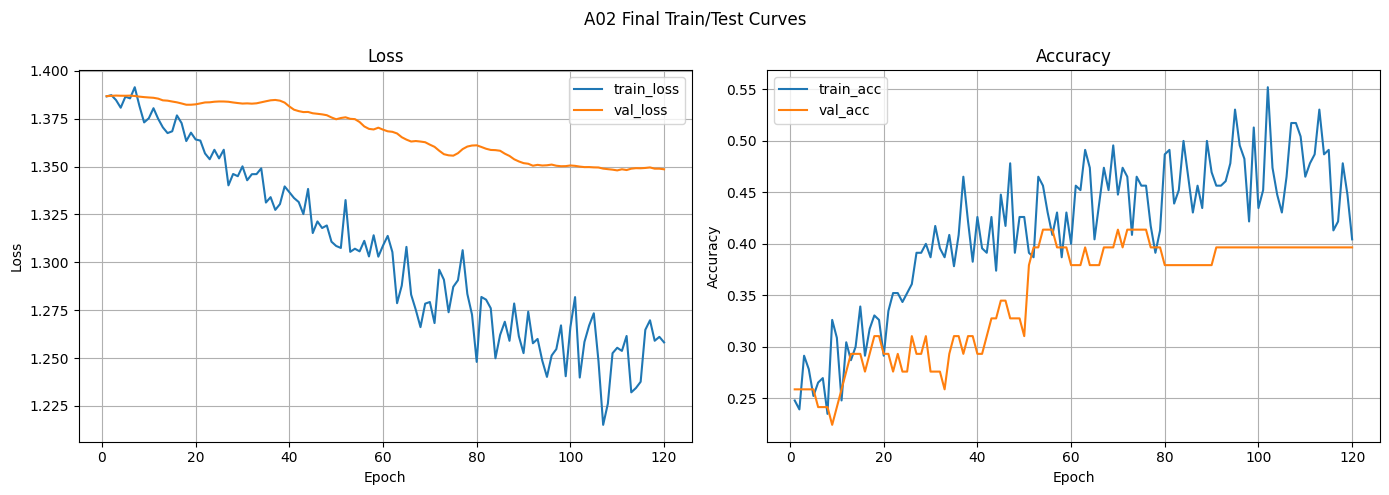

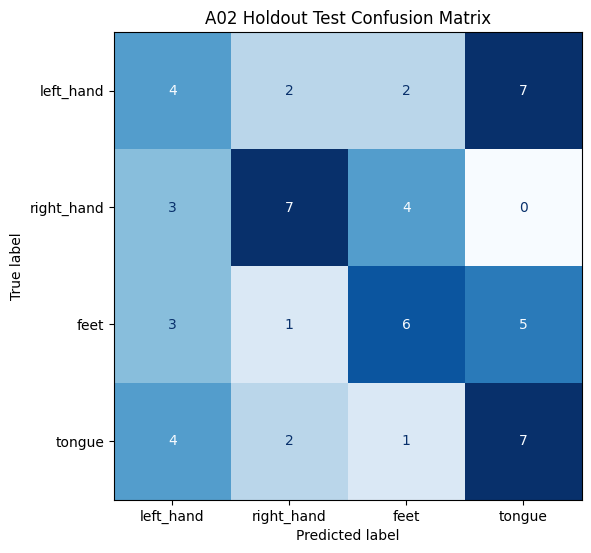


A02 Holdout Test Loss: 1.3747
A02 Holdout Test Acc : 0.4138
Per-class accuracy:
  left_hand: 0.2667
  right_hand: 0.5000
  feet: 0.4000
  tongue: 0.5000

Random 20-sample predictions for A02


/tmp/ipykernel_55/477152603.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,sample_index_in_test,true_label,pred_label,correct,prob_left_hand,prob_right_hand,prob_feet,prob_tongue
0,20,right_hand,feet,0,0.255859,0.247192,0.261963,0.235229
1,56,left_hand,tongue,0,0.230835,0.244629,0.258301,0.266113
2,44,feet,feet,1,0.259033,0.243652,0.260986,0.236450
3,13,tongue,tongue,1,0.227417,0.199463,0.272949,0.300293
4,1,left_hand,left_hand,1,0.270508,0.236816,0.243652,0.249023
5,40,feet,tongue,0,0.226074,0.208984,0.280518,0.284424
6,18,feet,feet,1,0.260254,0.225952,0.269287,0.244385
7,30,tongue,left_hand,0,0.276855,0.242432,0.253906,0.226562
8,7,left_hand,tongue,0,0.230469,0.206055,0.276367,0.287109
9,39,tongue,right_hand,0,0.251709,0.279053,0.239868,0.229126



####################################################################################################
SUBJECT A03
####################################################################################################

A03T.gdf
Available annotation codes: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]


/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


...

A03 Fold 3: 100%|██████████| 120/120 [00:05<00:00, 21.21it/s, best=0.7018, lr=0.00001, tr_acc=0.6763, tr_loss=0.8744, va_acc=0.6316, va_loss=0.9119]
/tmp/ipykernel_55/2653629609.py:45: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  amp_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)



A03 Fold 4 summary
Train size: 173

Train labels
  class 0 (left_hand): 42 (24.28%)
  class 1 (right_hand): 44 (25.43%)
  class 2 (feet): 43 (24.86%)
  class 3 (tongue): 44 (25.43%)
  total: 173

Val size: 57

Val labels
  class 0 (left_hand): 15 (26.32%)
  class 1 (right_hand): 14 (24.56%)
  class 2 (feet): 14 (24.56%)
  class 3 (tongue): 14 (24.56%)
  total: 57


A03 Fold 4: 100%|██████████| 120/120 [00:05<00:00, 21.07it/s, best=0.7368, lr=0.00001, tr_acc=0.6358, tr_loss=0.9154, va_acc=0.7018, va_loss=0.8866]
/tmp/ipykernel_55/3925417988.py:46: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  amp_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)



A03 CV summary
CV acc  : 0.7045 ± 0.0639
CV loss : 0.9529 ± 0.0735


A03 Final: 100%|██████████| 120/120 [00:07<00:00, 16.44it/s, best=0.7414, lr=0.00001, te_acc=0.6897, te_loss=0.8286, tr_acc=0.6826, tr_loss=0.8237]


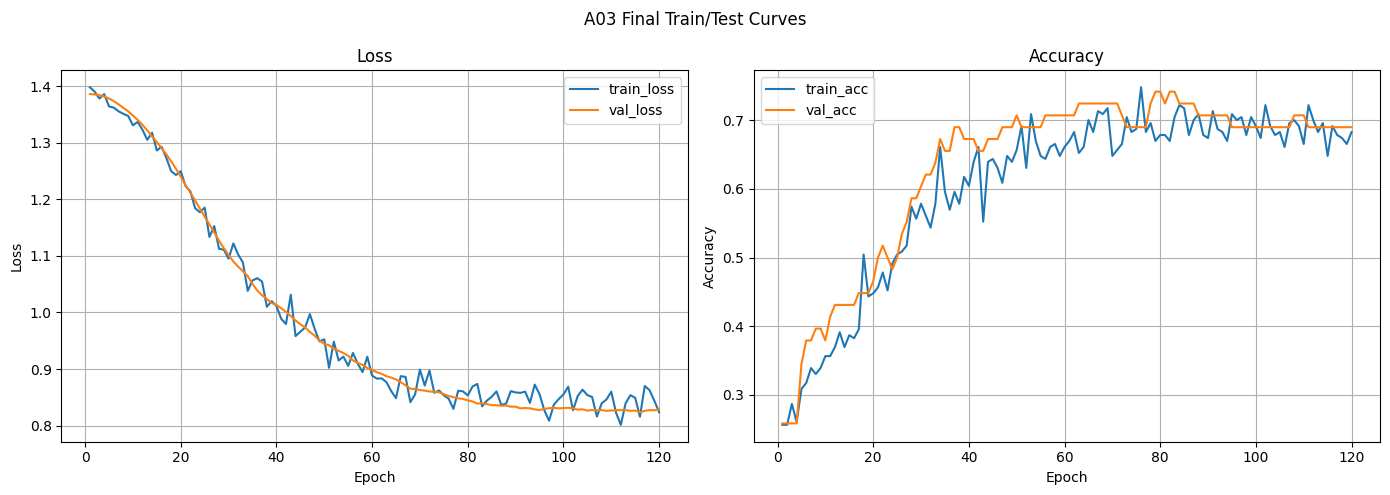

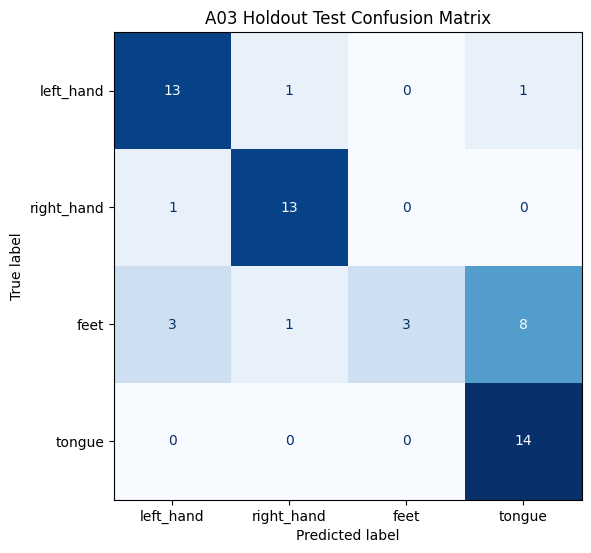


A03 Holdout Test Loss: 0.8471
A03 Holdout Test Acc : 0.7414
Per-class accuracy:
  left_hand: 0.8667
  right_hand: 0.9286
  feet: 0.2000
  tongue: 1.0000

Random 20-sample predictions for A03


/tmp/ipykernel_55/477152603.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,sample_index_in_test,true_label,pred_label,correct,prob_left_hand,prob_right_hand,prob_feet,prob_tongue
0,35,right_hand,right_hand,1,0.370605,0.465332,0.117554,0.046509
1,11,feet,tongue,0,0.183838,0.038605,0.132690,0.645020
2,21,right_hand,left_hand,0,0.461182,0.395752,0.114319,0.028671
3,46,tongue,tongue,1,0.047852,0.012215,0.169312,0.770508
4,34,feet,tongue,0,0.049530,0.114868,0.411133,0.424561
5,13,tongue,tongue,1,0.019440,0.013451,0.089233,0.877930
6,10,tongue,tongue,1,0.126953,0.102661,0.367188,0.403076
7,2,left_hand,left_hand,1,0.582520,0.239990,0.130249,0.047485
8,45,left_hand,left_hand,1,0.559082,0.199219,0.195679,0.046082
9,40,feet,right_hand,0,0.202881,0.292236,0.278809,0.225952



####################################################################################################
SUBJECT A04
####################################################################################################

A04T.gdf
Available annotation codes: [np.str_('1023'), np.str_('1072'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]


/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


...

A04 Fold 3: 100%|██████████| 120/120 [00:05<00:00, 20.39it/s, best=0.4211, lr=0.00001, tr_acc=0.4393, tr_loss=1.2967, va_acc=0.3509, va_loss=1.3261]
/tmp/ipykernel_55/2653629609.py:45: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  amp_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)



A04 Fold 4 summary
Train size: 173

Train labels
  class 0 (left_hand): 42 (24.28%)
  class 1 (right_hand): 44 (25.43%)
  class 2 (feet): 43 (24.86%)
  class 3 (tongue): 44 (25.43%)
  total: 173

Val size: 57

Val labels
  class 0 (left_hand): 15 (26.32%)
  class 1 (right_hand): 14 (24.56%)
  class 2 (feet): 14 (24.56%)
  class 3 (tongue): 14 (24.56%)
  total: 57


A04 Fold 4: 100%|██████████| 120/120 [00:05<00:00, 20.68it/s, best=0.3684, lr=0.00001, tr_acc=0.3988, tr_loss=1.2551, va_acc=0.2982, va_loss=1.2834]
/tmp/ipykernel_55/3925417988.py:46: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  amp_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)



A04 CV summary
CV acc  : 0.3741 ± 0.0412
CV loss : 1.3329 ± 0.0202


A04 Final: 100%|██████████| 120/120 [00:07<00:00, 15.91it/s, best=0.5000, lr=0.00001, te_acc=0.4655, te_loss=1.2264, tr_acc=0.4522, tr_loss=1.1927]


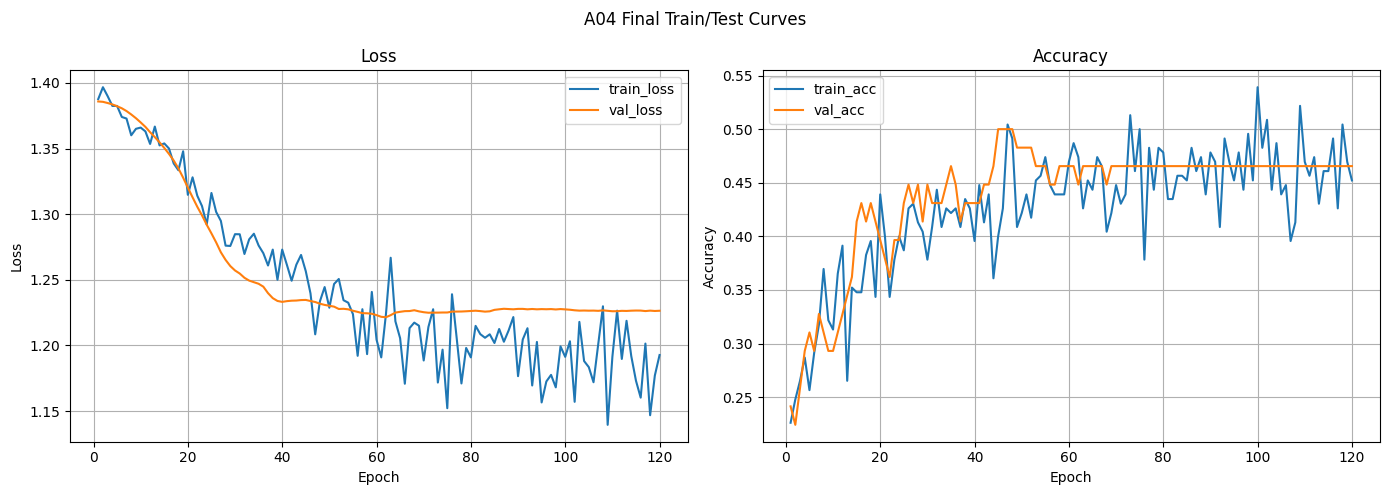

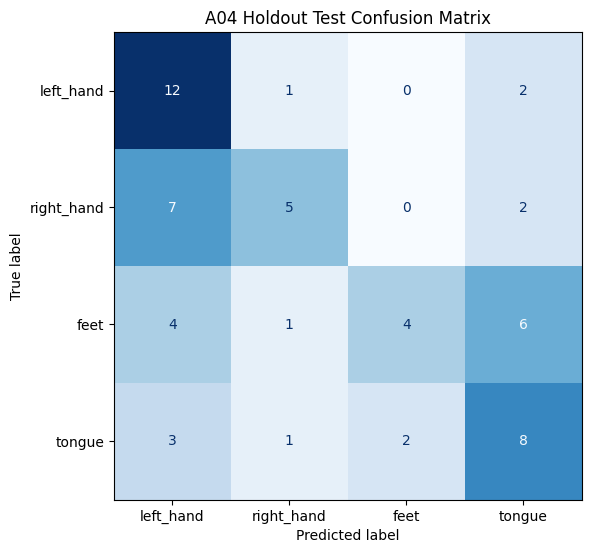


A04 Holdout Test Loss: 1.2347
A04 Holdout Test Acc : 0.5000
Per-class accuracy:
  left_hand: 0.8000
  right_hand: 0.3571
  feet: 0.2667
  tongue: 0.5714

Random 20-sample predictions for A04


/tmp/ipykernel_55/477152603.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,sample_index_in_test,true_label,pred_label,correct,prob_left_hand,prob_right_hand,prob_feet,prob_tongue
0,3,left_hand,left_hand,1,0.371094,0.298828,0.158447,0.171509
1,26,right_hand,right_hand,1,0.197388,0.325439,0.191650,0.285400
2,51,left_hand,left_hand,1,0.366455,0.270264,0.199341,0.164062
3,31,feet,feet,1,0.151611,0.177490,0.346191,0.324951
4,42,right_hand,left_hand,0,0.341797,0.305664,0.180664,0.171753
5,10,tongue,right_hand,0,0.256592,0.260254,0.246460,0.236694
6,13,tongue,feet,0,0.200195,0.202148,0.317139,0.280518
7,43,left_hand,left_hand,1,0.399414,0.324951,0.144165,0.131470
8,32,left_hand,left_hand,1,0.274414,0.274170,0.219849,0.231445
9,25,right_hand,left_hand,0,0.385010,0.310059,0.155396,0.149658



####################################################################################################
SUBJECT A05
####################################################################################################

A05T.gdf
Available annotation codes: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]


/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


...

A05 Fold 3: 100%|██████████| 120/120 [00:05<00:00, 20.77it/s, best=0.3684, lr=0.00001, tr_acc=0.4277, tr_loss=1.2644, va_acc=0.3509, va_loss=1.3651]
/tmp/ipykernel_55/2653629609.py:45: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  amp_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)



A05 Fold 4 summary
Train size: 173

Train labels
  class 0 (left_hand): 42 (24.28%)
  class 1 (right_hand): 44 (25.43%)
  class 2 (feet): 43 (24.86%)
  class 3 (tongue): 44 (25.43%)
  total: 173

Val size: 57

Val labels
  class 0 (left_hand): 15 (26.32%)
  class 1 (right_hand): 14 (24.56%)
  class 2 (feet): 14 (24.56%)
  class 3 (tongue): 14 (24.56%)
  total: 57


A05 Fold 4: 100%|██████████| 120/120 [00:05<00:00, 20.62it/s, best=0.3509, lr=0.00001, tr_acc=0.4509, tr_loss=1.2555, va_acc=0.3333, va_loss=1.3379]
/tmp/ipykernel_55/3925417988.py:46: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  amp_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)



A05 CV summary
CV acc  : 0.3824 ± 0.0298
CV loss : 1.3662 ± 0.0158


A05 Final: 100%|██████████| 120/120 [00:07<00:00, 16.20it/s, best=0.4138, lr=0.00001, te_acc=0.3966, te_loss=1.2862, tr_acc=0.4870, tr_loss=1.2019]


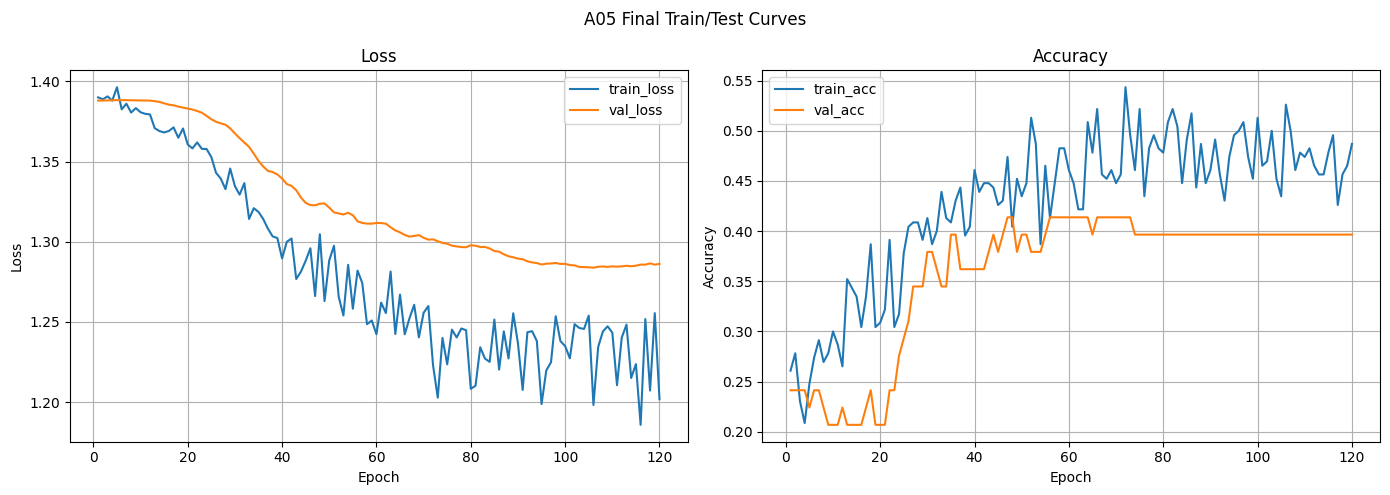

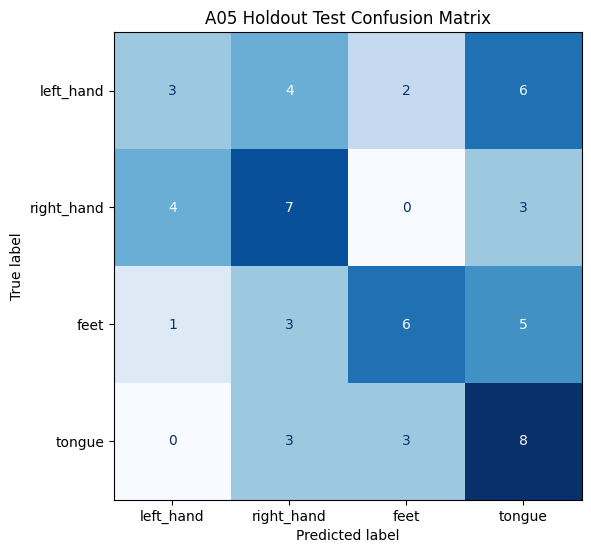


A05 Holdout Test Loss: 1.3228
A05 Holdout Test Acc : 0.4138
Per-class accuracy:
  left_hand: 0.2000
  right_hand: 0.5000
  feet: 0.4000
  tongue: 0.5714

Random 20-sample predictions for A05


/tmp/ipykernel_55/477152603.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,sample_index_in_test,true_label,pred_label,correct,prob_left_hand,prob_right_hand,prob_feet,prob_tongue
0,56,left_hand,feet,0,0.215088,0.224487,0.296631,0.263672
1,46,tongue,right_hand,0,0.213379,0.335693,0.255127,0.195801
2,45,left_hand,right_hand,0,0.245117,0.279541,0.247803,0.227417
3,13,tongue,tongue,1,0.194946,0.230591,0.278564,0.295898
4,31,feet,tongue,0,0.216309,0.198853,0.285645,0.299316
5,41,feet,tongue,0,0.224487,0.192627,0.284424,0.298584
6,9,left_hand,tongue,0,0.223999,0.219727,0.266846,0.289551
7,48,right_hand,right_hand,1,0.264893,0.313477,0.193970,0.227661
8,27,right_hand,left_hand,0,0.334961,0.246094,0.201294,0.217773
9,23,right_hand,right_hand,1,0.268799,0.335938,0.194092,0.201294



####################################################################################################
SUBJECT A06
####################################################################################################

A06T.gdf
Available annotation codes: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]


/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


...

A06 Fold 3: 100%|██████████| 120/120 [00:05<00:00, 20.11it/s, best=0.3158, lr=0.00001, tr_acc=0.3642, tr_loss=1.2993, va_acc=0.2807, va_loss=1.3762]
/tmp/ipykernel_55/2653629609.py:45: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  amp_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)



A06 Fold 4 summary
Train size: 173

Train labels
  class 0 (left_hand): 42 (24.28%)
  class 1 (right_hand): 44 (25.43%)
  class 2 (feet): 43 (24.86%)
  class 3 (tongue): 44 (25.43%)
  total: 173

Val size: 57

Val labels
  class 0 (left_hand): 15 (26.32%)
  class 1 (right_hand): 14 (24.56%)
  class 2 (feet): 14 (24.56%)
  class 3 (tongue): 14 (24.56%)
  total: 57


A06 Fold 4: 100%|██████████| 120/120 [00:05<00:00, 20.64it/s, best=0.3509, lr=0.00001, tr_acc=0.5376, tr_loss=1.2599, va_acc=0.2807, va_loss=1.3707]
/tmp/ipykernel_55/3925417988.py:46: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  amp_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)



A06 CV summary
CV acc  : 0.3434 ± 0.0243
CV loss : 1.3828 ± 0.0036


A06 Final: 100%|██████████| 120/120 [00:07<00:00, 16.00it/s, best=0.3793, lr=0.00001, te_acc=0.3621, te_loss=1.3114, tr_acc=0.4435, tr_loss=1.2674]


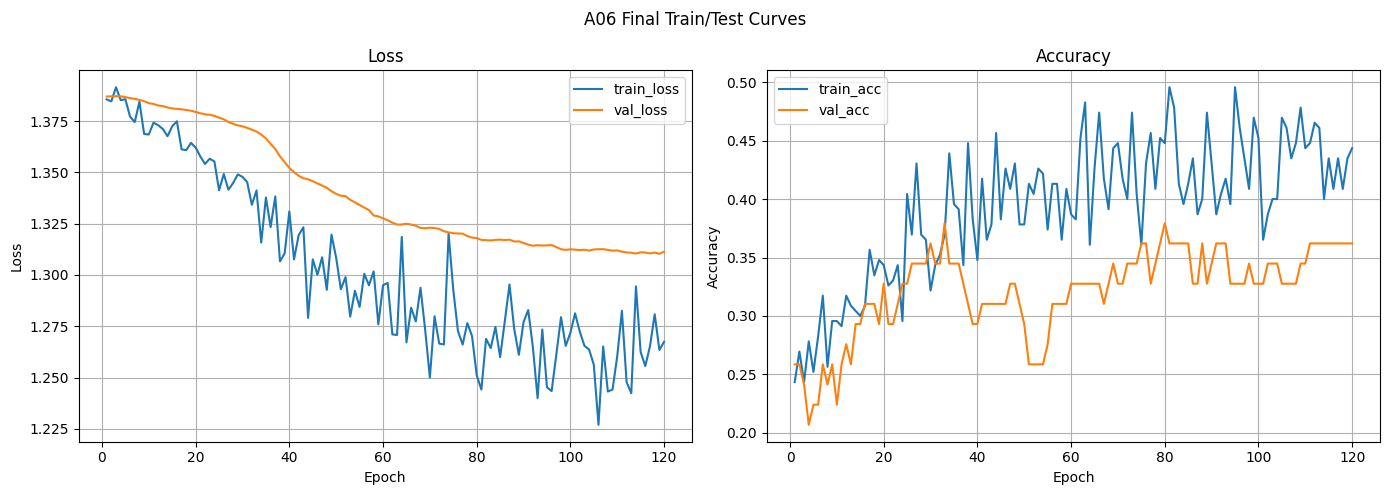

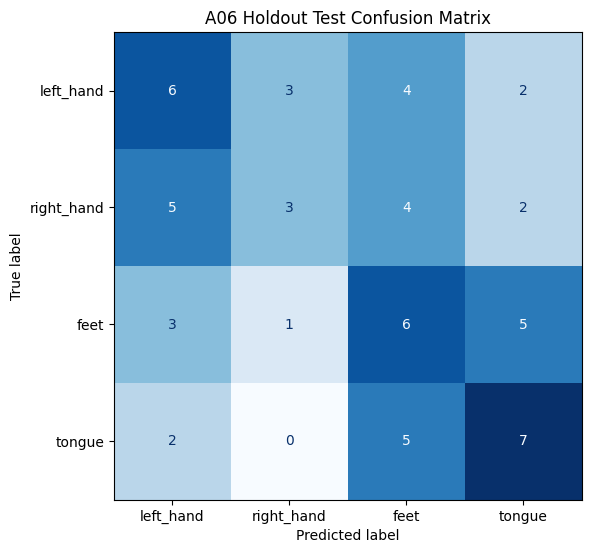


A06 Holdout Test Loss: 1.3699
A06 Holdout Test Acc : 0.3793
Per-class accuracy:
  left_hand: 0.4000
  right_hand: 0.2143
  feet: 0.4000
  tongue: 0.5000

Random 20-sample predictions for A06


/tmp/ipykernel_55/477152603.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,sample_index_in_test,true_label,pred_label,correct,prob_left_hand,prob_right_hand,prob_feet,prob_tongue
0,41,feet,feet,1,0.254395,0.242676,0.271973,0.230957
1,29,left_hand,feet,0,0.255127,0.258301,0.259521,0.227051
2,51,left_hand,tongue,0,0.243042,0.216675,0.256348,0.284180
3,47,right_hand,feet,0,0.261230,0.216919,0.265381,0.256348
4,14,tongue,feet,0,0.236572,0.244995,0.274658,0.243896
5,42,right_hand,feet,0,0.240356,0.247192,0.256836,0.255615
6,6,tongue,feet,0,0.249634,0.221313,0.275635,0.253418
7,31,feet,tongue,0,0.244385,0.241577,0.233887,0.280029
8,7,left_hand,feet,0,0.249756,0.249756,0.283203,0.217407
9,38,right_hand,left_hand,0,0.283691,0.239868,0.251221,0.225342



####################################################################################################
SUBJECT A07
####################################################################################################

A07T.gdf
Available annotation codes: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]


/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


...

A07 Fold 3: 100%|██████████| 120/120 [00:05<00:00, 20.59it/s, best=0.4561, lr=0.00001, tr_acc=0.4913, tr_loss=1.1857, va_acc=0.3860, va_loss=1.3281]
/tmp/ipykernel_55/2653629609.py:45: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  amp_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)



A07 Fold 4 summary
Train size: 173

Train labels
  class 0 (left_hand): 42 (24.28%)
  class 1 (right_hand): 44 (25.43%)
  class 2 (feet): 43 (24.86%)
  class 3 (tongue): 44 (25.43%)
  total: 173

Val size: 57

Val labels
  class 0 (left_hand): 15 (26.32%)
  class 1 (right_hand): 14 (24.56%)
  class 2 (feet): 14 (24.56%)
  class 3 (tongue): 14 (24.56%)
  total: 57


A07 Fold 4: 100%|██████████| 120/120 [00:05<00:00, 20.30it/s, best=0.4386, lr=0.00001, tr_acc=0.5607, tr_loss=1.1467, va_acc=0.4035, va_loss=1.2130]
/tmp/ipykernel_55/3925417988.py:46: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  amp_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)



A07 CV summary
CV acc  : 0.4651 ± 0.0224
CV loss : 1.2701 ± 0.0915


A07 Final: 100%|██████████| 120/120 [00:07<00:00, 16.08it/s, best=0.4483, lr=0.00001, te_acc=0.4483, te_loss=1.1249, tr_acc=0.6130, tr_loss=1.0592]


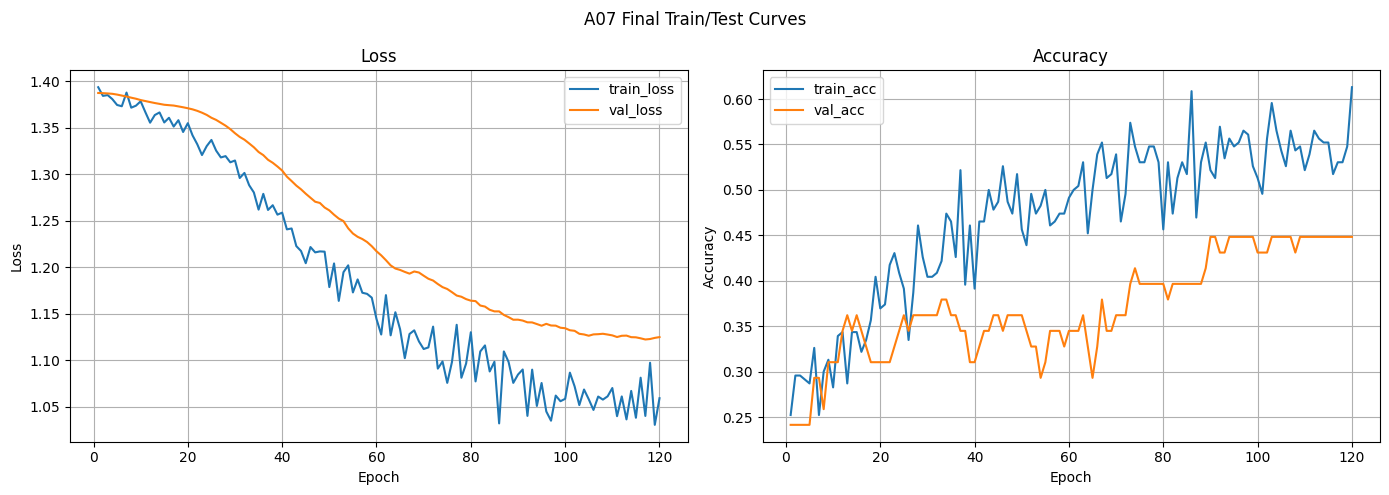

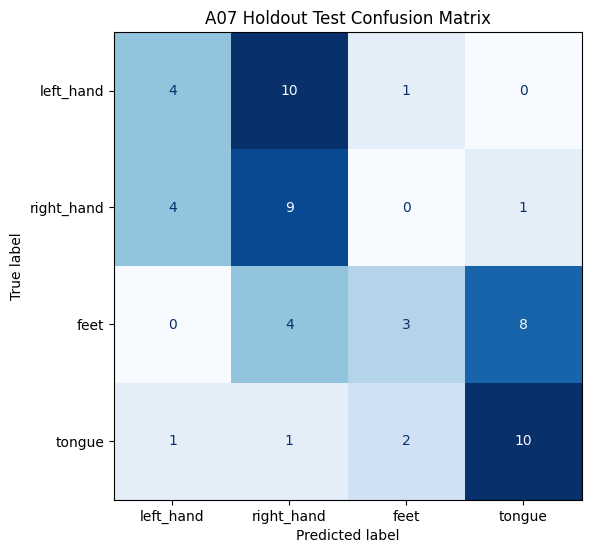


A07 Holdout Test Loss: 1.1437
A07 Holdout Test Acc : 0.4483
Per-class accuracy:
  left_hand: 0.2667
  right_hand: 0.6429
  feet: 0.2000
  tongue: 0.7143

Random 20-sample predictions for A07


/tmp/ipykernel_55/477152603.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,sample_index_in_test,true_label,pred_label,correct,prob_left_hand,prob_right_hand,prob_feet,prob_tongue
0,48,right_hand,right_hand,1,0.367432,0.426025,0.116882,0.089722
1,12,right_hand,left_hand,0,0.409668,0.379639,0.106689,0.103882
2,13,tongue,tongue,1,0.262451,0.245605,0.194946,0.296875
3,40,feet,feet,1,0.179810,0.264160,0.278564,0.277344
4,8,tongue,feet,0,0.055450,0.068848,0.520996,0.354980
5,2,left_hand,right_hand,0,0.243896,0.354248,0.226562,0.175293
6,28,feet,tongue,0,0.228516,0.198364,0.217529,0.355469
7,4,left_hand,left_hand,1,0.429932,0.355957,0.124695,0.089355
8,47,right_hand,left_hand,0,0.351807,0.311768,0.189697,0.146973
9,34,feet,tongue,0,0.268799,0.134521,0.168701,0.427979



####################################################################################################
SUBJECT A08
####################################################################################################

A08T.gdf
Available annotation codes: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]


/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


...

A08 Fold 3: 100%|██████████| 120/120 [00:05<00:00, 20.25it/s, best=0.6842, lr=0.00001, tr_acc=0.6474, tr_loss=0.9089, va_acc=0.6667, va_loss=0.9045]
/tmp/ipykernel_55/2653629609.py:45: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  amp_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)



A08 Fold 4 summary
Train size: 173

Train labels
  class 0 (left_hand): 42 (24.28%)
  class 1 (right_hand): 44 (25.43%)
  class 2 (feet): 43 (24.86%)
  class 3 (tongue): 44 (25.43%)
  total: 173

Val size: 57

Val labels
  class 0 (left_hand): 15 (26.32%)
  class 1 (right_hand): 14 (24.56%)
  class 2 (feet): 14 (24.56%)
  class 3 (tongue): 14 (24.56%)
  total: 57


A08 Fold 4: 100%|██████████| 120/120 [00:05<00:00, 20.57it/s, best=0.6140, lr=0.00001, tr_acc=0.6243, tr_loss=0.9790, va_acc=0.6140, va_loss=0.9586]
/tmp/ipykernel_55/3925417988.py:46: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  amp_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)



A08 CV summary
CV acc  : 0.6909 ± 0.0647
CV loss : 0.9428 ± 0.0338


A08 Final: 100%|██████████| 120/120 [00:07<00:00, 15.97it/s, best=0.7759, lr=0.00001, te_acc=0.7759, te_loss=0.8526, tr_acc=0.7174, tr_loss=0.8575]


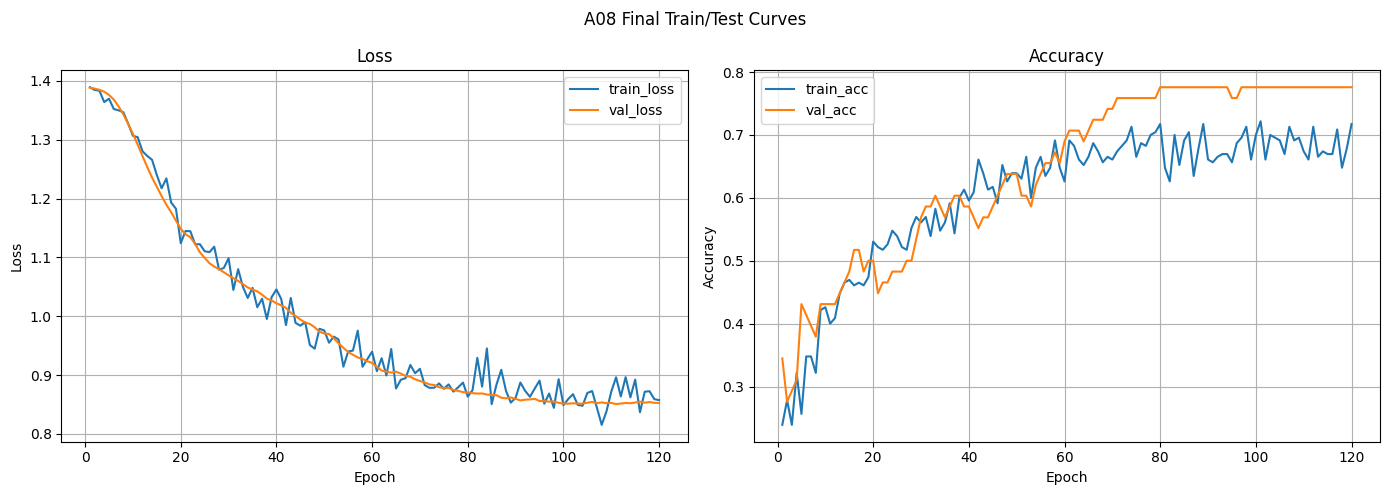

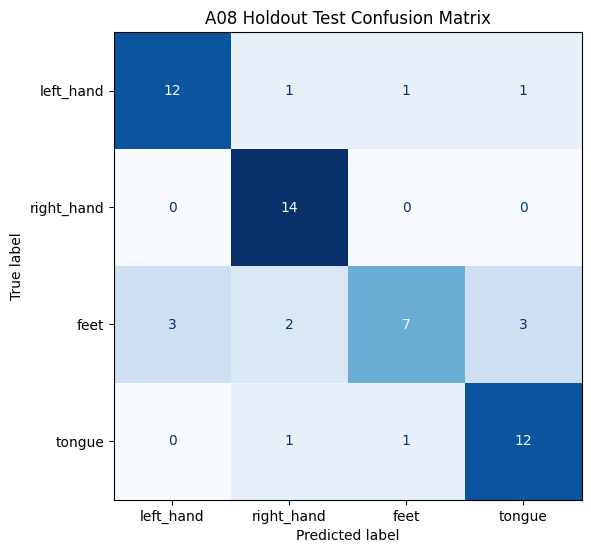


A08 Holdout Test Loss: 0.8706
A08 Holdout Test Acc : 0.7759
Per-class accuracy:
  left_hand: 0.8000
  right_hand: 1.0000
  feet: 0.4667
  tongue: 0.8571

Random 20-sample predictions for A08


/tmp/ipykernel_55/477152603.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,sample_index_in_test,true_label,pred_label,correct,prob_left_hand,prob_right_hand,prob_feet,prob_tongue
0,12,right_hand,right_hand,1,0.175781,0.302979,0.271729,0.249390
1,32,left_hand,left_hand,1,0.455078,0.122192,0.308594,0.114258
2,17,tongue,tongue,1,0.037537,0.209229,0.102356,0.650879
3,18,feet,tongue,0,0.153564,0.338867,0.149902,0.357666
4,57,feet,feet,1,0.252686,0.274414,0.339355,0.133667
5,53,tongue,tongue,1,0.006813,0.033997,0.027557,0.931641
6,2,left_hand,left_hand,1,0.384033,0.209717,0.355713,0.050537
7,35,right_hand,right_hand,1,0.301514,0.392578,0.258057,0.047607
8,11,feet,feet,1,0.243042,0.218750,0.303223,0.234863
9,8,tongue,right_hand,0,0.089966,0.392090,0.220093,0.297852



####################################################################################################
SUBJECT A09
####################################################################################################

A09T.gdf
Available annotation codes: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]


/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


...

A09 Fold 3: 100%|██████████| 120/120 [00:05<00:00, 20.44it/s, best=0.5965, lr=0.00001, tr_acc=0.5896, tr_loss=0.9566, va_acc=0.5789, va_loss=0.9507]
/tmp/ipykernel_55/2653629609.py:45: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  amp_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)



A09 Fold 4 summary
Train size: 173

Train labels
  class 0 (left_hand): 42 (24.28%)
  class 1 (right_hand): 44 (25.43%)
  class 2 (feet): 43 (24.86%)
  class 3 (tongue): 44 (25.43%)
  total: 173

Val size: 57

Val labels
  class 0 (left_hand): 15 (26.32%)
  class 1 (right_hand): 14 (24.56%)
  class 2 (feet): 14 (24.56%)
  class 3 (tongue): 14 (24.56%)
  total: 57


A09 Fold 4: 100%|██████████| 120/120 [00:05<00:00, 20.74it/s, best=0.6667, lr=0.00001, tr_acc=0.6185, tr_loss=0.8900, va_acc=0.6491, va_loss=0.9766]
/tmp/ipykernel_55/3925417988.py:46: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  amp_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)



A09 CV summary
CV acc  : 0.6822 ± 0.0567
CV loss : 0.9469 ± 0.0566


A09 Final: 100%|██████████| 120/120 [00:07<00:00, 15.98it/s, best=0.6897, lr=0.00001, te_acc=0.6724, te_loss=0.8152, tr_acc=0.7609, tr_loss=0.7600]


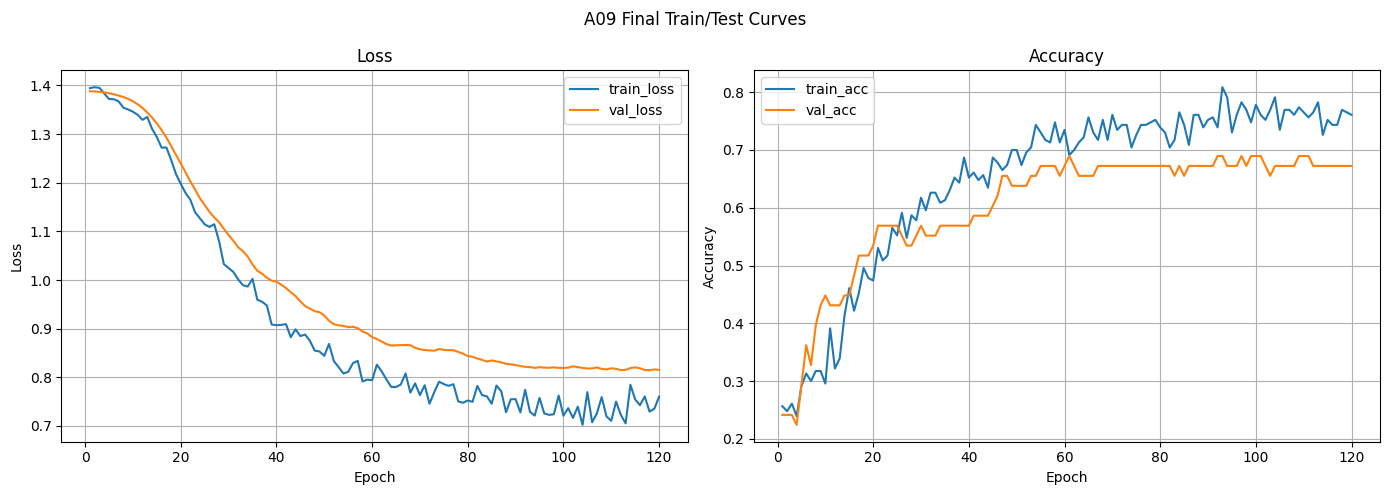

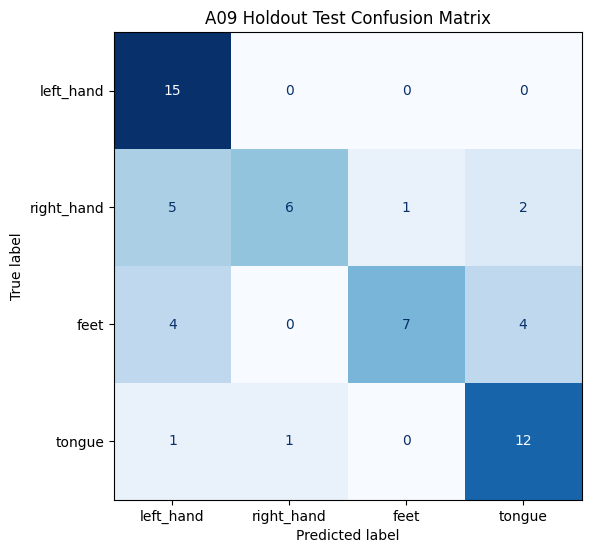


A09 Holdout Test Loss: 0.8788
A09 Holdout Test Acc : 0.6897
Per-class accuracy:
  left_hand: 1.0000
  right_hand: 0.4286
  feet: 0.4667
  tongue: 0.8571

Random 20-sample predictions for A09


/tmp/ipykernel_55/477152603.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,sample_index_in_test,true_label,pred_label,correct,prob_left_hand,prob_right_hand,prob_feet,prob_tongue
0,49,feet,feet,1,0.183350,0.189209,0.513184,0.114258
1,32,left_hand,left_hand,1,0.625000,0.174194,0.163086,0.037598
2,28,feet,tongue,0,0.161987,0.158936,0.173462,0.505859
3,2,left_hand,left_hand,1,0.661133,0.154297,0.165283,0.018997
4,6,tongue,tongue,1,0.018555,0.173462,0.093689,0.714355
5,31,feet,feet,1,0.241455,0.285156,0.375732,0.097656
6,50,right_hand,left_hand,0,0.515137,0.209351,0.224121,0.051117
7,54,tongue,tongue,1,0.021042,0.082947,0.162720,0.733398
8,25,right_hand,left_hand,0,0.480469,0.251465,0.226196,0.041779
9,16,tongue,tongue,1,0.034180,0.382080,0.156494,0.427246


In [16]:
# =========================
# 16. Run all subjects
# =========================
all_results = []

for sid in SUBJECTS:
    try:
        result = run_subject_pipeline(sid, visualize=(sid == "A01"))
        all_results.append(result)
    except Exception as e:
        print(f"Failed on {sid}: {e}")

In [17]:
# =========================
# 17. Overall summary
# =========================
if len(all_results) > 0:
    results_df = pd.DataFrame([
        {
            "subject": r["subject"],
            "cv_mean_acc": r["cv_mean_acc"],
            "cv_std_acc": r["cv_std_acc"],
            "cv_mean_loss": r["cv_mean_loss"],
            "cv_std_loss": r["cv_std_loss"],
            "holdout_test_loss": r["holdout_test_loss"],
            "holdout_test_acc": r["holdout_test_acc"],
            **{f"class_{k}": v for k, v in r["per_class_acc"].items()}
        }
        for r in all_results
    ])

    display(results_df)

    print("\nOverall holdout test performance across subjects")
    print(f"Mean acc ± std  = {results_df['holdout_test_acc'].mean():.4f} ± {results_df['holdout_test_acc'].std():.4f}")
    print(f"Mean loss ± std = {results_df['holdout_test_loss'].mean():.4f} ± {results_df['holdout_test_loss'].std():.4f}")

    results_df.to_csv(ARTIFACTS_DIR / "all_subject_results.csv", index=False)

,subject,cv_mean_acc,cv_std_acc,cv_mean_loss,cv_std_loss,holdout_test_loss,holdout_test_acc,class_left_hand,class_right_hand,class_feet,class_tongue
0,A01,0.599894,0.033401,0.887617,0.037841,1.006070,0.637931,0.533333,0.785714,0.400000,0.857143
1,A02,0.325923,0.031471,1.384055,0.005117,1.374747,0.413793,0.266667,0.500000,0.400000,0.500000
2,A03,0.704477,0.063948,0.952918,0.073483,0.847101,0.741379,0.866667,0.928571,0.200000,1.000000
3,A04,0.374093,0.041248,1.332923,0.020201,1.234670,0.500000,0.800000,0.357143,0.266667,0.571429
4,A05,0.382411,0.029849,1.366176,0.015812,1.322754,0.413793,0.200000,0.500000,0.400000,0.571429
5,A06,0.343391,0.024279,1.382785,0.003642,1.369882,0.379310,0.400000,0.214286,0.400000,0.500000
6,A07,0.465064,0.022366,1.270132,0.091537,1.143702,0.448276,0.266667,0.642857,0.200000,0.714286
7,A08,0.690941,0.064692,0.942754,0.033799,0.870568,0.775862,0.800000,1.000000,0.466667,0.857143
8,A09,0.682169,0.056675,0.946877,0.056555,0.878776,0.689655,1.000000,0.428571,0.466667,0.857143



Overall holdout test performance across subjects
Mean acc ± std  = 0.5556 ± 0.1556
Mean loss ± std = 1.1165 ± 0.2208
